# Deep Leakage from Gradients attack in CNN

This notebook contains the code for the attack Deep Leakage from gradients (DLG) and imporved-DLG (iDLG) on LeNet model (CNN).

In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, Subset
import matplotlib.pyplot as plt
import copy
import math

### Utility functions

* `show_reconstruciton` saves reconstructions as images.
* `moving_avg` computes the [simple moving average](https://en.wikipedia.org/wiki/Moving_average) of a vector.
* `load_mnist_lenet` laods and returns the dataloader of MNIST dataset configured ready to feed into LeNet model.
* `total_variation_loss` Computes Total Variation loss for a flattened image tensor.

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def show_reconstructions_with_originals(orig_x, rec_x_per_epoch, save_path, cmap="gray"):
    """
    orig_x: list of length batch_size each entry is a flattened image (same format as reconstructions)

    rec_x_per_epoch: list of length num_epochs each element is a list of length batch_size each entry is a flattened reconstructed image

    Layout:
        rows    = batch elements
        columns = [orig | recon] repeated per epoch
    """

    num_epochs = len(rec_x_per_epoch)
    batch_size = len(rec_x_per_epoch[0])

    fig, axes = plt.subplots(
        batch_size,
        num_epochs * 2,
        figsize=(num_epochs * 3, batch_size * 1.5),
        squeeze=False
    )

    for e in range(num_epochs):
        for b in range(batch_size):

            # Origingal
            x_orig = orig_x[b]

            if hasattr(x_orig, "detach"):
                x_orig = x_orig.detach().cpu().numpy()

            x_orig = np.squeeze(x_orig)

            ax_orig = axes[b, 2 * e]

            if cmap == "gray":
                img_orig = x_orig.reshape(24, 24)
                ax_orig.imshow(img_orig, cmap=cmap)
            else:
                img_orig = x_orig.reshape(3, 24, 24)
                img_orig = np.transpose(img_orig, (1, 2, 0))
                ax_orig.imshow(img_orig)

            ax_orig.set_xticks([])
            ax_orig.set_yticks([])


            # Reconstruction
            x_rec = rec_x_per_epoch[e][b]

            if hasattr(x_rec, "detach"):
                x_rec = x_rec.detach().cpu().numpy()

            x_rec = np.squeeze(x_rec)

            ax_rec = axes[b, 2 * e + 1]

            if cmap == "gray":
                img_rec = x_rec.reshape(24, 24)
                ax_rec.imshow(img_rec, cmap=cmap)
            else:
                img_rec = x_rec.reshape(3, 24, 24)
                img_rec = np.transpose(img_rec, (1, 2, 0))
                ax_rec.imshow(img_rec)

            ax_rec.set_xticks([])
            ax_rec.set_yticks([])


            # Set red border
            for ax in [ax_orig, ax_rec]:
                for spine in ax.spines.values():
                    spine.set_edgecolor("red")
                    spine.set_linewidth(0.5)


            # Titles
            if b == 0:
                ax_orig.set_title(f"Orig", fontsize=24, pad=2)
                ax_rec.set_title(f"Rec", fontsize=24, pad=2)


    plt.subplots_adjust(
        left=0,
        right=1,
        top=1,
        bottom=0,
        wspace=0.03,
        hspace=0
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()

def show_reconstructions(rec_x_per_epoch,
                         save_path,
                         cmap="gray"):
    """
    rec_x_per_epoch:
        list of length num_epochs
        each element is a list of length batch_size
        each entry is a flattened (1024,) image

    Output layout:
        rows    = batch elements
        columns = epochs
    """

    num_epochs = len(rec_x_per_epoch)
    batch_size = len(rec_x_per_epoch[0])

    fig, axes = plt.subplots(
        batch_size,
        num_epochs,
        figsize=(num_epochs * 1.5, batch_size * 1.5),
        squeeze=False
    )

    for e in range(num_epochs):
        for b in range(batch_size):

            x_rec = rec_x_per_epoch[e][b]

            # handle torch tensors
            if hasattr(x_rec, "detach"):
                x_rec = x_rec.detach().cpu().numpy()

            x_rec = np.squeeze(x_rec)
            #img = x_rec.reshape(32, 32)
            if cmap=='gray':
                img = x_rec.reshape(32, 32)
                ax = axes[b, e]
                ax.imshow(img, cmap=cmap)
            else:
                img = x_rec.reshape(3, 24, 24)
                img = np.transpose(img, (1, 2, 0)) # make it matplotlib compatible.
                ax = axes[b, e]
                ax.imshow(img)
            

            ax.set_xticks([])
            ax.set_yticks([])

            # thin red border
            for spine in ax.spines.values():
                spine.set_edgecolor("red")
                spine.set_linewidth(0.5)

            # epoch label on top row
            if b == 0:
                ax.set_title(f"Ep. {e+1}", fontsize=28, pad=2)

    # remove all spacing
    plt.subplots_adjust(
        left=0,
        right=1,
        top=1,
        bottom=0,
        wspace=0.03,
        hspace=0
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()

def moving_avg(x, window=10):
    x = np.array(x)
    return np.convolve(x, np.ones(window)/window, mode="valid")

def load_mnist_lenet(batch_size=64, n_train=None, n_test=None, data_dir='./data/mnist'):
    """
    Loads MNIST resized to 32x32 and returns PyTorch DataLoaders
    ready for LeNet.

    Args:
        batch_size: batch size for training
        n_train: optional subset size for training
        n_test: optional subset size for test
        data_dir: str the directory of the mnist dataset.

    Returns:
        train_loader, test_loader
    """

    transform = transforms.Compose([
        transforms.Resize(32),
        transforms.ToTensor(),   # -> (1, 32, 32)
    ])

    train_set = datasets.MNIST(
        root=data_dir,
        train=True,
        download=True,
        transform=transform
    )

    test_set = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

    # Optional subsampling
    if n_train is not None:
        idx = torch.randperm(len(train_set))[:n_train]
        train_set = Subset(train_set, idx)

    if n_test is not None:
        idx = torch.randperm(len(test_set))[:n_test]
        test_set = Subset(test_set, idx)

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, test_loader


def total_variation_loss(x, height=32, width=32):
    """
    Batched Total Variation Loss.

    Args:
        x: torch.Tensor of shape
            (B, H*W)      or
            (B, 1, H, W)

    Returns:
        scalar tensor = mean TV across batch
    """

    # if flattened → reshape
    if x.dim() == 2:
        B = x.size(0)
        img = x.view(B, 1, height, width)

    # already image-shaped
    elif x.dim() == 4:
        img = x

    else:
        raise ValueError("x must be (B,H*W) or (B,1,H,W)")

    # horizontal & vertical diffs
    diff_h = img[:, :, :, 1:] - img[:, :, :, :-1]
    diff_v = img[:, :, 1:, :] - img[:, :, :-1, :]

    # TV per image
    tv_per_img = (
        diff_h.pow(2).sum(dim=(1,2,3)) +
        diff_v.pow(2).sum(dim=(1,2,3))
    )

    # mean over batch
    return tv_per_img.mean()


def get_cifar10_subset_cnn_dataloaders(n_train=4000, n_test=1000, batch_size=1, data_dir="../data", seed=42):
    """
    Returns subset DataLoaders of CIFAR-10 for CNN training (no augmentation).

    Parameters:
        n_train (int): number of training samples
        n_test (int): number of test samples
        batch_size (int): batch size
        data_dir (str): dataset location
        seed (int): reproducibility seed

    Returns:
        train_loader, test_loader
    """

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2023, 0.1994, 0.2010)
        )
    ])

    train_dataset = datasets.CIFAR10(
        root=data_dir,
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = datasets.CIFAR10(
        root=data_dir,
        train=False,
        download=True,
        transform=transform
    )

    generator = torch.Generator().manual_seed(seed)

    train_indices = torch.randperm(len(train_dataset), generator=generator)[:n_train]
    test_indices = torch.randperm(len(test_dataset), generator=generator)[:n_test]

    train_subset = Subset(train_dataset, train_indices)
    test_subset = Subset(test_dataset, test_indices)

    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_subset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, test_loader

def get_abadi_cifar10_dataloaders(batch_size=128, data_dir="../data"):

    train_transform = transforms.Compose([
        transforms.RandomCrop(24),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2
        ),
        transforms.ToTensor(),
    ])

    test_transform = transforms.Compose([
        transforms.CenterCrop(24),
        transforms.ToTensor(),
    ])

    train_dataset = datasets.CIFAR10(
        root=data_dir,
        train=True,
        download=True,
        transform=train_transform
    )

    test_dataset = datasets.CIFAR10(
        root=data_dir,
        train=False,
        download=True,
        transform=test_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, test_loader

train_loader, test_loader = get_abadi_cifar10_dataloaders()

for X, y in train_loader:
    print(X.shape)
    break

/home/tom/miniconda3/envs/dlg/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


torch.Size([128, 3, 24, 24])


### Define Model

Next we define the [LeNet](https://en.wikipedia.org/wiki/LeNet) model as well as some useful functions:

* `grad_norm` calculates and returns the norm of a model.
* `weights_init` initializes the weights of a model at random 

In [3]:
def grad_norm(model, norm_type=2):
    """
    Computes the norm of gradients of all parameters in a model.

    Args:
        model (nn.Module): PyTorch model with computed gradients
        norm_type (float): type of norm (2 for L2, 1 for L1, float('inf') for max)

    Returns:
        float: gradient norm
    """
    total_norm = 0.0

    if norm_type == float('inf'):
        total_norm = max(
            p.grad.abs().max().item()
            for p in model.parameters()
            if p.grad is not None
        )
        return total_norm

    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(norm_type)
            total_norm += param_norm.item() ** norm_type

    total_norm = total_norm ** (1.0 / norm_type)
    return total_norm



def weights_init(m):
    if hasattr(m, "weight"):
        m.weight.data.uniform_(-0.5, 0.5)
    if hasattr(m, "bias"):
        m.bias.data.uniform_(-0.5, 0.5)

class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        act = nn.Sigmoid
        self.body = nn.Sequential(
            nn.Conv2d(1, 12, kernel_size=5, padding=5//2, stride=2),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=2),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=1),
            act(),
            nn.Conv2d(12, 12, kernel_size=5, padding=5//2, stride=1),
            act(),
        )
        self.fc = nn.Sequential(
            nn.Linear(768 , 10)
        )

    def forward(self, x):
        x = self.body(x)
        x = torch.flatten(x, 1)
        # print(out.size())
        x = self.fc(x)
        return x

class CIFAR10CNN(nn.Module):
    def __init__(self):
        super(CIFAR10CNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32×32 -> 16×16
            nn.Dropout2d(0.25),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 16×16 -> 8×8
            nn.Dropout2d(0.25),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Dropout2d(0.25),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout2d(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class AbadiCIFAR10CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 3 * 3, 384),
            nn.ReLU(),

            nn.Linear(384, 384),
            nn.ReLU(),

            nn.Linear(384, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Vanilla train of the model

Train the model without any additive noise for later comparisons.

In [4]:
def train(model, train_loader, test_loader, epochs, optimizer, loss_function):
    loss_per_epoch = []
    test_acc_per_epoch = []
    train_acc_per_epoch = []
    for epoch in range(epochs):
        model.train()
        tot_loss = 0
        correct, total = 0, 0
        for i, data in enumerate(train_loader, 0):
            x_batch, y_batch = data
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = loss_function(outputs, y_batch)
            loss.backward()
            optimizer.step()
            tot_loss += loss.item()

            outputs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
        loss_per_epoch.append(tot_loss)
        train_acc_per_epoch.append(correct/total)
    
        # Evaluate after each epoch
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                outputs = torch.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
            acc = correct / total
            test_acc_per_epoch.append(acc)
    
        print(f"Epoch {epoch+1}: Test acc: {test_acc_per_epoch[epoch]:.4f}, train acc: {train_acc_per_epoch[epoch]:.4f}, epoch loss: {loss_per_epoch[epoch]:.4f}")
    
    return test_acc_per_epoch, train_acc_per_epoch, loss_per_epoch, tot_loss
            

### Notes on noiseless training.

* For the **full** CIFAR10 dataset the LeNet architecture with 12 filters achieves ~60% accuracy. 

In [15]:
#train_loader, test_loader = load_mnist_lenet(batch_size=1, n_train=4000, n_test=1000, data_dir='../data/mnist')
train_loader, test_loader = get_abadi_cifar10_dataloaders()
#model = LeNet()
model = AbadiCIFAR10CNN()
#model.apply(weights_init)
loss_function = nn.CrossEntropyLoss(reduction="mean")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay = 0.0) 
epochs = 500

test_acc_per_epoch, train_acc_per_epoch, loss_per_epoch, cummulative_loss = train(model, train_loader, test_loader, epochs, optimizer, loss_function)

Epoch 1: Test acc: 0.3231, train acc: 0.2355, epoch loss: 790.4555
Epoch 2: Test acc: 0.3719, train acc: 0.3173, epoch loss: 708.0356
Epoch 3: Test acc: 0.4122, train acc: 0.3576, epoch loss: 670.3550
Epoch 4: Test acc: 0.4407, train acc: 0.3848, epoch loss: 649.2772
Epoch 5: Test acc: 0.4497, train acc: 0.4038, epoch loss: 630.2976
Epoch 6: Test acc: 0.4805, train acc: 0.4252, epoch loss: 612.3040
Epoch 7: Test acc: 0.4772, train acc: 0.4407, epoch loss: 598.7957
Epoch 8: Test acc: 0.4974, train acc: 0.4521, epoch loss: 585.8981
Epoch 9: Test acc: 0.5173, train acc: 0.4646, epoch loss: 574.3194
Epoch 10: Test acc: 0.5247, train acc: 0.4763, epoch loss: 563.4699
Epoch 11: Test acc: 0.5371, train acc: 0.4867, epoch loss: 553.7094
Epoch 12: Test acc: 0.5402, train acc: 0.4910, epoch loss: 546.8475
Epoch 13: Test acc: 0.5568, train acc: 0.5021, epoch loss: 540.4385
Epoch 14: Test acc: 0.5609, train acc: 0.5087, epoch loss: 533.1796
Epoch 15: Test acc: 0.5635, train acc: 0.5159, epoch loss

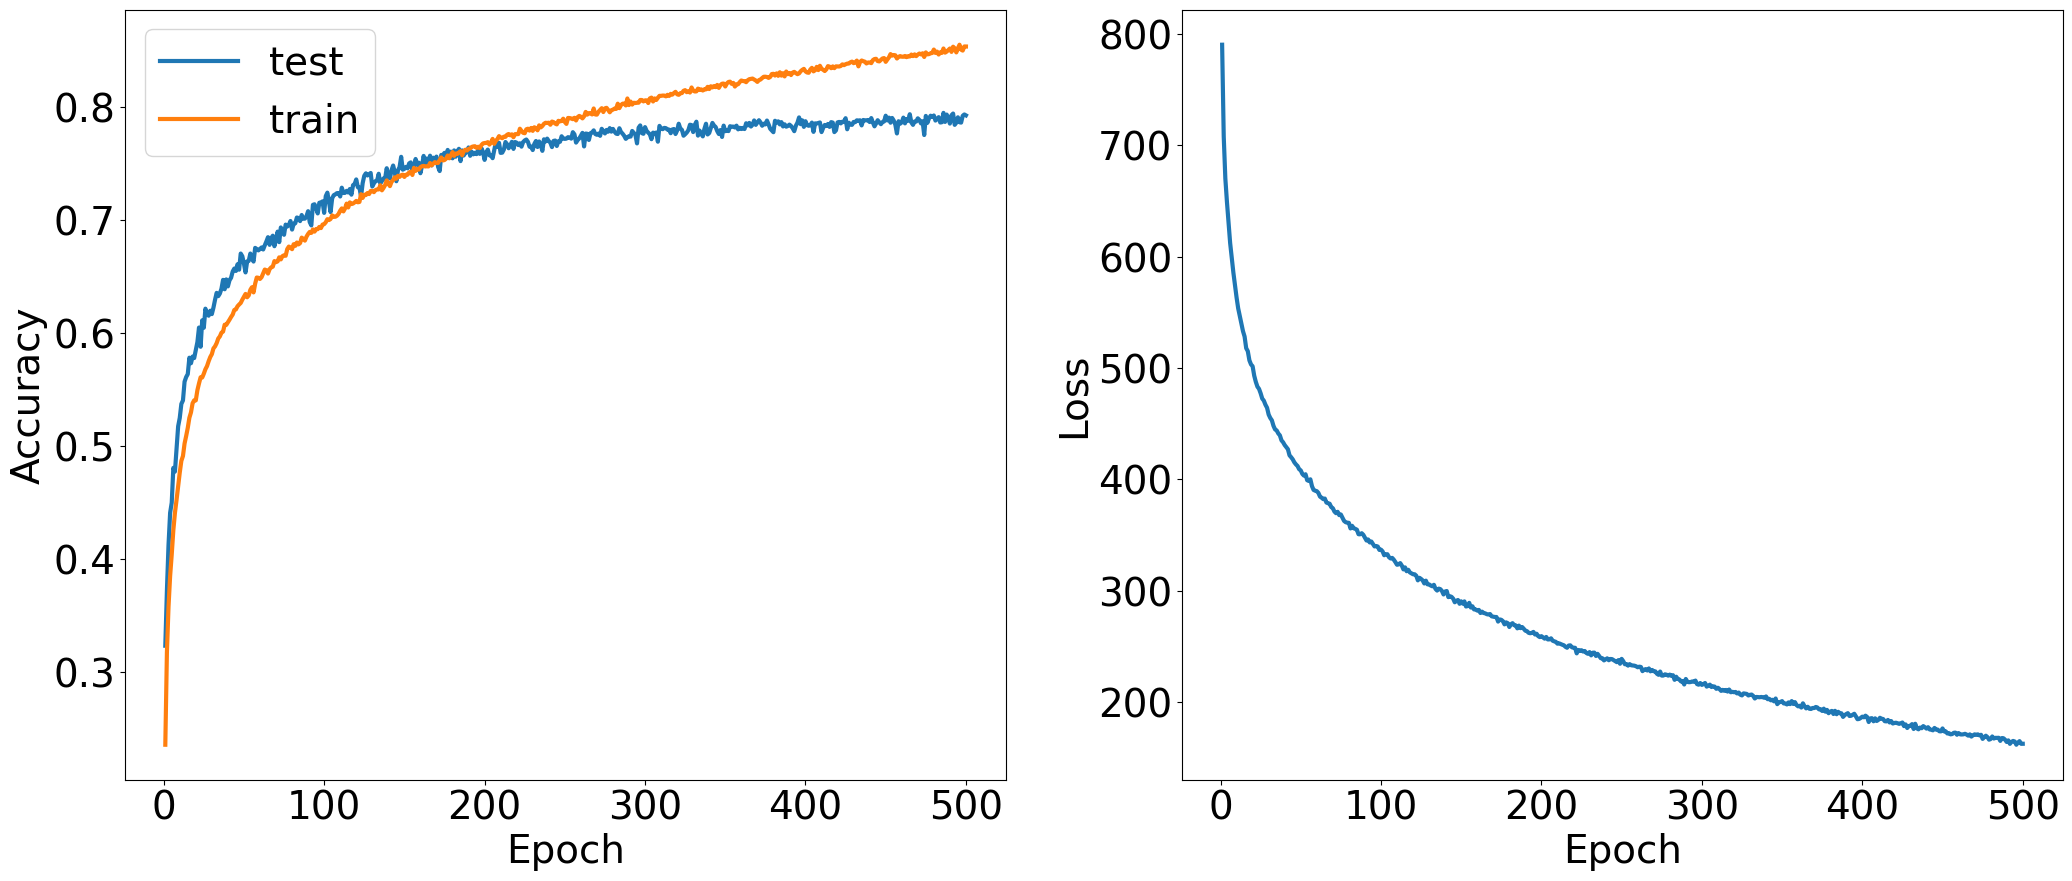

In [20]:
plt.figure(figsize=(25, 10))
plt.rcParams.update({'font.size': 28})
plt.subplot(1,2,1)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(range(1, epochs+1), test_acc_per_epoch , linestyle='-', linewidth=3, label='test')
plt.plot(range(1, epochs+1), train_acc_per_epoch , linestyle='-', linewidth=3, label='train')
plt.legend()

plt.subplot(1,2,2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(range(1, epochs+1), loss_per_epoch , linestyle='-', linewidth=3, label='noisless')

#plt.show()
plt.savefig('./noiseless_cifar10_cnn.png')

## Train with noise

In [5]:
def get_grad_vector(grad):
    """
    Returns all gradients of model parameters as a single flattened vector.
    Assumes backward() has already been called.
    """
    grad_list = []

    for param in grad:
        if param.grad is not None:
            grad_list.append(param.grad.view(-1))
        else:
            # If a parameter has no gradient, append zeros of same size
            grad_list.append(torch.zeros_like(param).view(-1))

    return torch.cat(grad_list)

In [6]:
def cross_entropy_for_onehot(pred, target):
    return torch.mean(torch.sum(- target * F.log_softmax(pred, dim=-1), 1))

def add_noise_to_grads(model, snr):
    # Compute gradient norm and size
    grad_sq_sum = 0.0
    num_elems = 0
    grad_tuple = []

    for p in model.parameters():
        if p.grad is not None:
    
            if not torch.isfinite(p.grad).all():
                p.grad.data = torch.nan_to_num(
                    p.grad.data,
                    nan=0.0,
                    posinf=1e4,
                    neginf=-1e4
                )
    
            grad_sq_sum += torch.sum(p.grad.data ** 2)
            num_elems += p.grad.numel()
       
    # Compute sigma from SNR
    if snr != None:
        rms_grad = torch.sqrt(grad_sq_sum / num_elems + 1e-8)
        sigma = rms_grad / torch.sqrt(torch.tensor(snr + 1e-8))
        sigma = torch.clamp(sigma, min=1e-8, max=100.0)
        if math.isnan(sigma):
            sigma = 1e12
    else:
        sigma = 1e12 # infinity (Very very large)
        
    # Add Gaussian noise to each gradient
    for p in model.parameters():
        if p.grad is not None:
            noise = torch.randn_like(p.grad) * sigma
            if snr != None:
                p.grad.add_(noise)
            
            grad_tuple.append(p.grad)
            
    grad = tuple(g.detach().clone() for g in grad_tuple)
    #grad_tuple = tuple(grad_tuple)
    return sigma, grad_tuple

    
def dlg_attack(original_dy_dx, model, criterion=cross_entropy_for_onehot, loss_function="grad_diff", batch_size=1):
    '''
    iDLG attack.
    original_dy_dx: the gradient of the model's training shared to the clients.
    model: the model to be attacked
    criterion: the loss funtion used by the model
    loss_funtion: the loss funtion used by th attack. 'grad_diif' is the original, 'cosine similarity' for the cosine similarity loss funtion.
    '''
    # generate dummy data and label. Use three channels for CIFAR10 and 1 for MNIST (uncomment below).
    #dummy_data = torch.randn((batch_size,1,32,32)).requires_grad_(True)
    dummy_data = torch.randn((batch_size,3,24,24)).requires_grad_(True)
    dummy_label = torch.randn((batch_size,10), requires_grad=True)
    optimizer = torch.optim.Adam([dummy_data, dummy_label], lr=0.1)
    #optimizer = torch.optim.LBFGS([dummy_data,], lr=1)
    #criterion_iDLG = nn.CrossEntropyLoss()

    history = []
    convergance = 1e10
    prev_loss = 1e10
    current_loss = 1e10
    iters = 0
    while (iters < 3000 and current_loss>1e-4):
        if iters != 0:
            prev_loss = current_loss
        def flatten_gradients(grad_list):
            return torch.cat([g.reshape(-1) for g in grad_list])
        def closure():
            optimizer.zero_grad()
    
            pred = model(dummy_data)
            dummy_onehot_label = F.softmax(dummy_label, dim=-1)
            #last_bias_grad = original_dy_dx[-1]   
            #label_pred = torch.argmin(last_bias_grad).view(1)
            #dummy_loss = criterion_iDLG(pred, label_pred)
            dummy_loss = criterion(pred, dummy_onehot_label) 
            dummy_dy_dx = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)
            #dummy_grad_vec = flatten_gradients(dummy_dy_dx)
            #orig_grad_vec = flatten_gradients(original_dy_dx)

            grad_diff = 0
            grad_count = 0
            total = 0
            lambda_tv = 1e-4
            tv_loss = total_variation_loss(dummy_data,  height=dummy_data.shape[2], width=dummy_data.shape[3])
            if loss_function=='cosine similarity':   
                for gx, gy in zip(dummy_dy_dx, original_dy_dx):
                    cos = F.cosine_similarity(gx.reshape(1, -1), gy.reshape(1, -1), eps=1e-8)
                    
                    n = gy.numel()
                    #grad_diff += n * (1 - cos)
                    grad_diff += (1 - cos)
                    total += n
                
                #grad_diff = grad_diff / total
                grad_diff = grad_diff + lambda_tv * tv_loss

            elif loss_function == 'nDLG':
                for gx, gy in zip(dummy_dy_dx, original_dy_dx): 
                    n = gy.numel()
                    gx_norm = torch.norm(gx, p=2)
                    gy_norm = torch.norm(gy, p=2)
    
                    gx_normalized = gx / (gx_norm)
                    gy_normalized = gy / (gy_norm)
    
                    grad_diff += ((gx_normalized - gy_normalized) ** 2).sum()
                    total += n
                #grad_diff = grad_diff / total
                grad_diff += lambda_tv * tv_loss
            else:
                for gx, gy in zip(dummy_dy_dx, original_dy_dx): 
                    n = gy.numel()
                    grad_diff += ((gx - gy) ** 2).sum()
                    total += n
                #grad_diff = grad_diff / total
                grad_diff += lambda_tv * tv_loss

            grad_diff.backward()
    
            return grad_diff
    
        current_loss = optimizer.step(closure)
        dummy_data.data.clamp_(0,1)
        dummy_label.data.clamp_(-10,10)
        current_loss = current_loss.item()
        convergance = np.abs(current_loss - prev_loss)/np.abs(current_loss)
        history.append(dummy_data.cpu())
        iters += 1
       
    print(f'Iters: {iters}, Loss: {current_loss:.4f}, Convergance value: {convergance:.6f}, rec_label: {torch.argmax(dummy_label)}')
    return history

def noisy_train(model, train_loader, test_loader, epochs, optimizer, loss_function, snr, attack='grad_diff', batch_size=1):
    loss_per_epoch = []
    test_acc_per_epoch = []
    train_acc_per_epoch = []
    rec_x_per_epoch = []
    rec_error_per_epoch = []
    grad_norm_per_epoch = []
    
    
    for epoch in range(epochs):
        model.train()
        tot_loss = 0
        correct, total = 0, 0
        rec_error, sigma = 0.0, 0.0

        rec_error_per_epoch.append([])
        grad_norm_per_epoch.append([])
        for i, data in enumerate(train_loader, 0):
            x_batch, y_batch = data
            optimizer.zero_grad()

            outputs = model(x_batch)
            loss = loss_function(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)
            sigma, grad = add_noise_to_grads(model, snr) # Here we calculate std based on snr and add noise to gradients.

            '''
            # Perform attack. 
            if (i == 0): 
                # Share the gradients with clients.
                # Make a deep copy of the model so we avoid conflicts with backpropagation.
                frozen_model = copy.deepcopy(model).eval()

                
                # Try the attack many times to avoid bad reconstructions due to bad initialization of data.
                rec_error = 0.0
                for trial in range(1):    
                    history = dlg_attack(grad, frozen_model, loss_function=attack, batch_size=batch_size)

                    rec_x_batched = history[-1].detach()
                    rec = rec_x_batched.view(batch_size, -1)
                    x = x_batch.detach().view(batch_size, -1)
                    
                    sim = F.cosine_similarity(rec, x, dim=1)
                    rec_error = sim.mean().item()
                    if rec_error > 0.6:
                        break 
                
                if i == 0:
                    rec_x_per_epoch.append(rec)
                rec_error_per_epoch[epoch].append(rec_error)
                grad_norm_per_epoch[epoch].append(grad_norm(model))
                print(f'Iter: {i+1}, rec_error: ', rec_error, f',grad L2 norm: {grad_norm_per_epoch[epoch][-1]}, Sigma: {sigma}, orig. label:{y_batch}')
                show_reconstructions_with_originals(x_batch ,rec_x_per_epoch, f"./grid{batch_size}_{attack}_{snr}_cifar.png", cmap='rgb')
                return [],[],[],[],[],rec_error_per_epoch[0]
            '''
            optimizer.step()
    

            tot_loss += loss.item()

            outputs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
        

        loss_per_epoch.append(tot_loss)
        train_acc_per_epoch.append(correct / total)

        # Evaluation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                outputs = torch.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()

        acc = correct / total
        test_acc_per_epoch.append(acc)
        
        #print(f"Epoch {epoch+1}: Test acc: {acc:.4f}, train acc: {train_acc_per_epoch[epoch]:.4f}, epoch loss: {loss_per_epoch[epoch]:.4f}, reconstruction error: {rec_error:.4f}")
        print(f"Epoch {epoch+1}: Test acc: {acc:.4f}, train acc: {train_acc_per_epoch[epoch]:.4f}, epoch loss: {loss_per_epoch[epoch]:.4f}")

    '''
    # Decide colormap by see the number of channels in data
    if len(x_batch[0]) == 1:
        show_reconstructions(rec_x_per_epoch, f"./grid_{attack}_{snr}.png")
    else:
        #show_reconstructions(rec_x_per_epoch, f"./grid_{attack}_{snr}.png", cmap='rgb')
        show_reconstructions_with_originals(x_batch ,rec_x_per_epoch, f"./grid_{attack}_{snr}.png", cmap='rgb')
    '''
    #error_grads = (rec_error_per_epoch, grad_norm_per_epoch)
    return test_acc_per_epoch, train_acc_per_epoch, loss_per_epoch, tot_loss, rec_x_per_epoch#, error_grads


### Notes for the CIFAR10 experiments

1. Added tv loss to DLG with λ=1e-4. DLG seems to produce better reconstructions than cosine similarity.
2. The cosine similarity metric is not that accurate. High cosine similarity does not always provide "good" reconstruction. With "good" we now mean idintified by human eye.
3. Experimental setup:
   * CIFAR10 dataset with 50000 training images and 10000 test images. During training, data augmentation consisted of random cropping from 32×32 to 24×24 pixels, random horizontal flipping with probability 0.5, and color jittering with brightness and contrast variation factors sampled uniformly from the interval [0.8,1.2]. These augmentations improve robustness to spatial and illumination variations while preserving semantic image structure. Test images were center-cropped to 24×24 pixels without augmentation.
   * The model consists of two convolutional blocks followed by a three-layer fully connected classifier. Each convolutional block contains a 5×5 convolution with 64 filters, stride of size 1, a ReLU activation and 2×2 max pooling. After feature extraction, the resulting 64×3×3 tensor is flattened and passed through two fully connected layers with 384 hidden units each and ReLU activations. A final linear layer maps the representation to 10 output logits corresponding to the CIFAR-10 classes. This architecture follows the compact CNN design used in the Abadi et al. training pipeline for small-resolution image classification.
   * Due to computational reasons the attack is perform only on the first step of the training.
   * The attack is performed using all three loss gradient-matching functions described in the previous section. In addition, we added a total variation (TV) loss with $\lambda=10^{-4}$ to each of the three objective functions. The optimization procedure is run for 3,000 iterations.

In [10]:
B=2
train_loader, test_loader = get_abadi_cifar10_dataloaders()

snr_arr = [0.01, 0.1, 1, None]
#snr_arr = [None]
attacks = ['iDLG', 'nDLG', 'cosine similarity']
errors_snr = {a: [] for a in attacks}

for attack in attacks:
    for i, snr in enumerate(snr_arr):
        torch.manual_seed(0)
        print(f'Starting experiment for snr: {snr}, attack: {attack}')

        train_loader, test_loader = get_abadi_cifar10_dataloaders(batch_size=B)
        model = AbadiCIFAR10CNN()
        loss_function = nn.CrossEntropyLoss(reduction="mean")
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
        #snr = 0.01
        epochs = 1        
        
        noisy_test_acc_per_epoch, noisy_train_acc_per_epoch, noisy_loss_per_epoch, noisy_cummulative_loss, noisy_rec_x_per_epoch, error_grads = noisy_train(model, train_loader, test_loader, 
                                                                                                                                                           epochs, optimizer, loss_function, snr, attack=attack,
                                                                                                                                                            batch_size=B)
        
        #errors = error_grads[0]
        #grads = error_grads[1]
        
        errors_snr[attack].append(error_grads[0])
        print(errors_snr)

/home/tom/miniconda3/envs/dlg/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Starting experiment for snr: 0.01, attack: iDLG
Iters: 3000, Loss: 84.6048, Convergance value: 0.000026, rec_label: 4
Iter: 1, rec_error:  0.739547610282898 ,grad L2 norm: 9.24159923870703, Sigma: 0.013276329264044762, orig. label:tensor([4, 5])
{'iDLG': [0.739547610282898], 'nDLG': [], 'cosine similarity': []}
Starting experiment for snr: 0.1, attack: iDLG
Iters: 3000, Loss: 8.5108, Convergance value: 0.000047, rec_label: 4
Iter: 1, rec_error:  0.9042734503746033 ,grad L2 norm: 3.0485047223677344, Sigma: 0.004198345821350813, orig. label:tensor([4, 5])
{'iDLG': [0.739547610282898, 0.9042734503746033], 'nDLG': [], 'cosine similarity': []}
Starting experiment for snr: 1, attack: iDLG
Iters: 3000, Loss: 0.8842, Convergance value: 0.007228, rec_label: 4
Iter: 1, rec_error:  0.9673874378204346 ,grad L2 norm: 1.2983386028114086, Sigma: 0.0013276335084810853, orig. label:tensor([4, 5])
{'iDLG': [0.739547610282898, 0.9042734503746033, 0.9673874378204346], 'nDLG': [], 'cosine similarity': []}


In [ ]:
B=1
train_loader, test_loader = get_abadi_cifar10_dataloaders()
epochs = 200

snr_arr = [0.01, 0.1, 1, None]
#snr_arr = [None]
test_acc = []
train_acc = []
loss = []

for i, snr in enumerate(snr_arr):
    
    torch.manual_seed(0)
    print(f'Starting experiment for snr: {snr}')

    train_loader, test_loader = get_abadi_cifar10_dataloaders(batch_size=B)
    model = AbadiCIFAR10CNN()
    loss_function = nn.CrossEntropyLoss(reduction="mean")
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
     
        
    noisy_test_acc_per_epoch, noisy_train_acc_per_epoch, noisy_loss_per_epoch, noisy_cummulative_loss, noisy_rec_x_per_epoch = noisy_train(model, train_loader, test_loader, 
                                                                                                                                                           epochs, optimizer, loss_function, snr, attack='DLG',
                                                                                                                                                         batch_size=B)


    test_acc.append(noisy_test_acc_per_epoch) 
    train_acc.append(noisy_train_acc_per_epoch)
    loss.append(noisy_loss_per_epoch)

Starting experiment for snr: 0.01


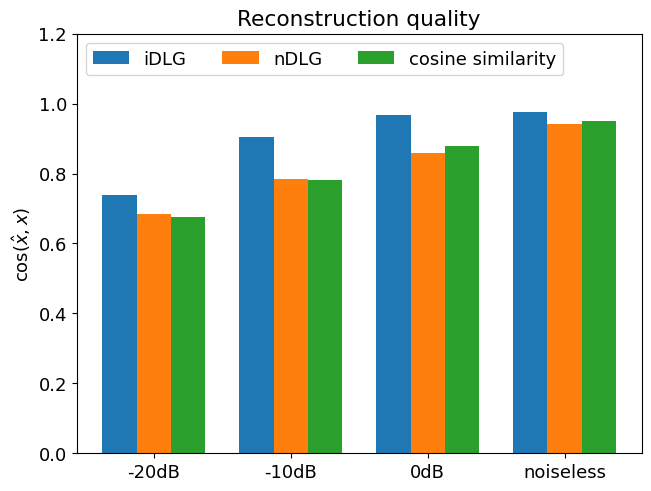

In [11]:
noise_values = ("-20dB", "-10dB", "0dB", "noiseless" )
similarities = errors_snr

x = np.arange(len(noise_values))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

#plt.figure(figsize=(10, 20))
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(layout='constrained')

for attribute, similarity in similarities.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, similarity, width, label=attribute)
    #ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel(r'$\cos(\hat{x}, x)$')
ax.set_title('Reconstruction quality')
ax.set_xticks(x + width, noise_values)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 1.2)

plt.savefig('./bars_B2.png')


In [82]:
arr = []
for e in errors:
    if e != []:
        arr.append(e)
np.save('errors_cnn_cifar_noiseless.npy', np.array(arr))
np.save('acc_cnn_cifar_noiseless.npy', noisy_test_acc_per_epoch)
np.save('train_loss_cnn_cifar_noiseless.npy', noisy_loss_per_epoch)

In [175]:
snr_arr = [0.01, 0.1, 1, None]
#snr_arr = [None]
epochs = 10
B=1
train_loader, test_loader = load_mnist_lenet(batch_size=B, n_train=4000, n_test=1000, data_dir='../data/mnist')

attacks = ['iDLG', 'nDLG', 'cosine similarity']
errors_snr = {a: [] for a in attacks}
for attack in attacks:
    for i, snr in enumerate(snr_arr):
        torch.manual_seed(0)
        print(f'Starting experiment for snr: {snr}, attack: {attack}')
        
        model = LeNet()
        model.apply(weights_init)
        loss_function = nn.CrossEntropyLoss(reduction="mean")
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        noisy_test_acc_per_epoch, noisy_train_acc_per_epoch, noisy_loss_per_epoch, noisy_cummulative_loss, noisy_rec_x_per_epoch, error_grads = noisy_train(model, train_loader, test_loader, 
                                                                                                                                                   epochs, optimizer, loss_function, snr, attack=attack,
                                                                                                                                                   batch_size=B)
        errors = np.array(error_grads[0])
        grads = np.array(error_grads[1])
    
        errors_snr[attack].append(errors)

Starting experiment for snr: None, attack: iDLG
Iters: 3000, Loss: 0.0042, Convergance value: 0.001216, rec_label: 31
Iter: 1, rec_error:  0.4625232219696045 ,grad L2 norm: 10.00000036295634, Sigma: 1000000000000.0, orig. label:tensor([9, 1, 4, 1, 6, 9, 9, 0, 6, 1, 6, 2, 1, 1, 7, 7])
Epoch 1: Test acc: 0.5760, train acc: 0.3053, epoch loss: 571.8966, reconstruction error: 0.4625
Iters: 3000, Loss: 0.8444, Convergance value: 0.044664, rec_label: 35
Iter: 1, rec_error:  0.33447790145874023 ,grad L2 norm: 5.930288256570256, Sigma: 1000000000000.0, orig. label:tensor([7, 2, 1, 8, 2, 5, 3, 9, 5, 7, 2, 1, 8, 5, 5, 6])
Epoch 2: Test acc: 0.8120, train acc: 0.7163, epoch loss: 229.4748, reconstruction error: 0.3345
Iters: 3000, Loss: 0.1430, Convergance value: 0.005373, rec_label: 87
Iter: 1, rec_error:  0.37480664253234863 ,grad L2 norm: 3.3896381099836455, Sigma: 1000000000000.0, orig. label:tensor([8, 7, 2, 7, 2, 6, 0, 8, 2, 7, 8, 4, 6, 4, 8, 5])
Epoch 3: Test acc: 0.8410, train acc: 0.8327

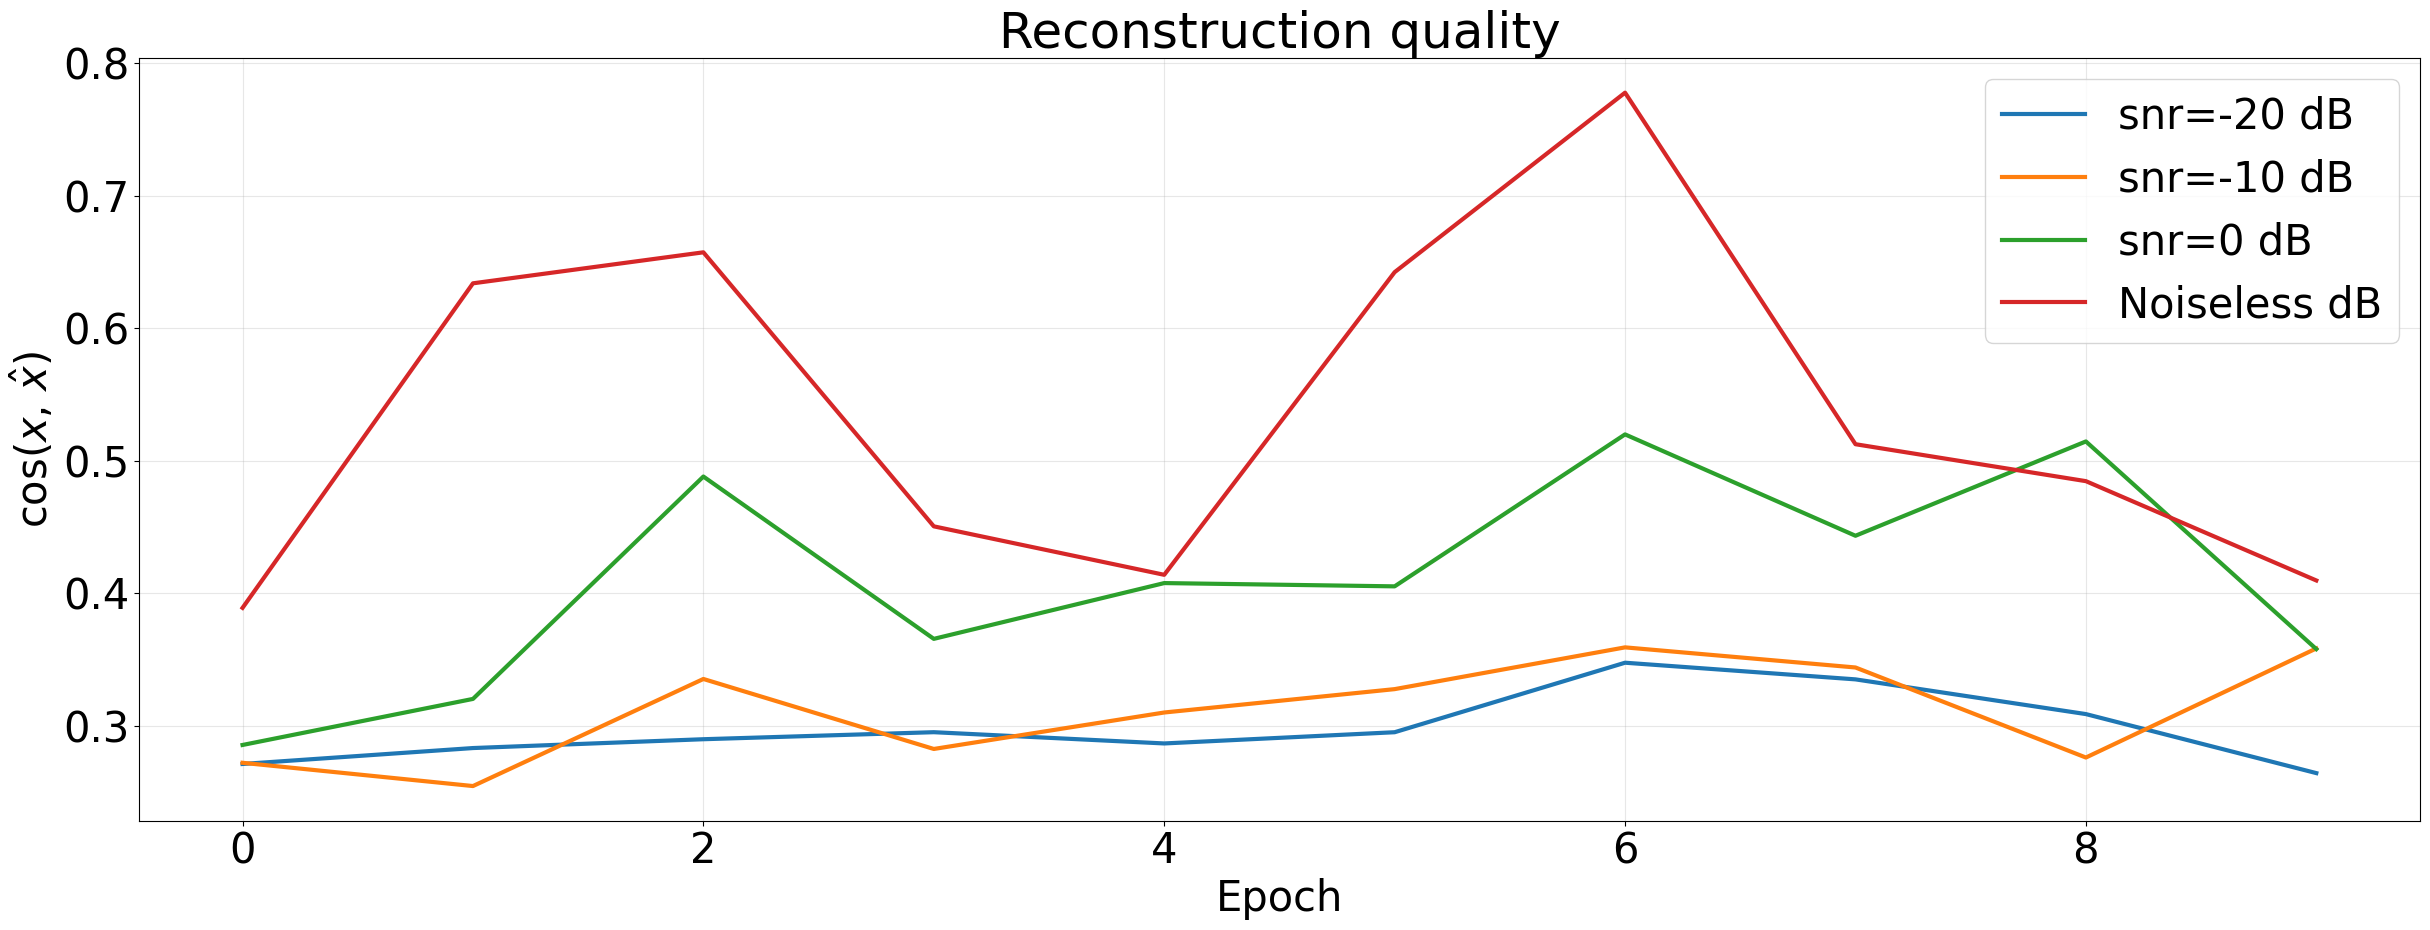

In [174]:
plt.figure(figsize=(25, 10))
plt.rcParams.update({'font.size': 30})

plt.plot(range(epochs), errors_snr['cosine similarity'][0], linewidth=3, label=f'snr={int(10*np.log10(snr_arr[0]))} dB')
plt.plot(range(epochs), errors_snr['cosine similarity'][1], linewidth=3, label=f'snr={int(10*np.log10(snr_arr[1]))} dB')
plt.plot(range(epochs), errors_snr['cosine similarity'][2], linewidth=3, label=f'snr={int(10*np.log10(snr_arr[2]))} dB')
plt.plot(range(epochs), errors_snr['cosine similarity'][3], linewidth=3, label=f'Noiseless dB')
#plt.plot(range(epochs), test_acc_per_epoch[0:epochs] , linestyle='-', linewidth=3, label='noisless')
plt.title('Reconstruction quality')
plt.xlabel('Epoch')
plt.ylabel(r'cos($x$, $\hat{x}$)')
plt.xticks(range(0, epochs, 2))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./figure.png')